<a href="https://colab.research.google.com/github/sabharwal-monish/Deep-Learning-Tensor-Flow/blob/main/data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import PIL
import matplotlib.pyplot as plt
import cv2
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
import tensorflow as tf
import os

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
print("Actual path:", data_dir)
!ls -l $(dirname $data_dir)


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Actual path: /root/.keras/datasets/flower_photos
total 223456
drwxr-xr-x 3 root root      4096 Oct 18 11:02 flower_photos
-rw-r--r-- 1 root root 228813984 Oct 18 11:02 flower_photos_archive


In [3]:
import pathlib
data_dir = pathlib.Path("/root/.keras/datasets/flower_photos/flower_photos")

print(data_dir)


/root/.keras/datasets/flower_photos/flower_photos


In [4]:
list(data_dir.glob('*/*.jpg'))[:5]
image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)


Total images: 3670


In [5]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/8775267816_726ddc6d92_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/1666341535_99c6f7509f_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3661675690_ed2d05fa5f_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3742155164_14b557a51c_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/6016195304_75306bb79a.jpg')]

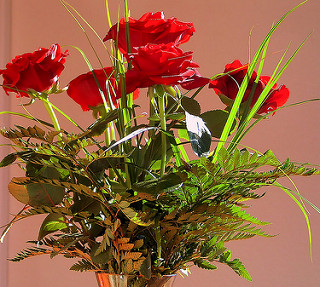

In [6]:
PIL.Image.open(str(roses[1]))

In [7]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}


In [8]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape


(240, 320, 3)

In [9]:
cv2.resize(img, (180, 180)).shape

(180, 180, 3)

In [12]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resized_img = cv2.resize(img, (180,180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])

In [13]:
X = np.array(X)
y = np.array(y)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [15]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [16]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 936ms/step - accuracy: 0.2665 - loss: 1.9514
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 77s 884ms/step - accuracy: 0.5219 - loss: 1.1321
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 932ms/step - accuracy: 0.6392 - loss: 0.9286
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 79s 908ms/step - accuracy: 0.6887 - loss: 0.7829
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 906ms/step - accuracy: 0.7820 - loss: 0.5855
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 906ms/step - accuracy: 0.8637 - loss: 0.4056
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 78s 905ms/step - accuracy: 0.9330 - loss: 0.2254
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 79s 918ms/step - accuracy: 0.9612 - loss: 0.1451
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 76s 888ms/step - accuracy: 0.9784 - loss: 0.0781
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 883ms/step - accuracy: 0.9915 - loss: 0.0313
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 891ms/step - accuracy: 0.9774 - loss: 0.0794
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 77

In [17]:
model.evaluate(X_test, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 0.5701 - loss: 843.9360


[820.0494384765625, 0.570806086063385]

In [18]:
y_pred = model.predict(X_test_scaled)

29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 245ms/step


In [21]:
#Data Augmentation

from tensorflow import keras
from tensorflow.keras import layers

img_height = 180
img_width = 180

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


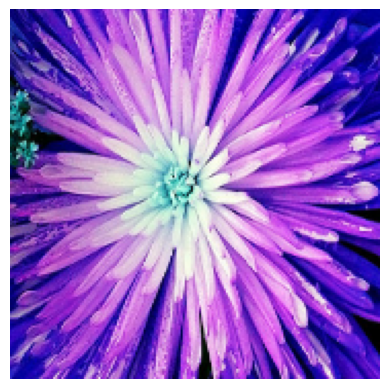

In [22]:
plt.axis('off')
plt.imshow(X[0])

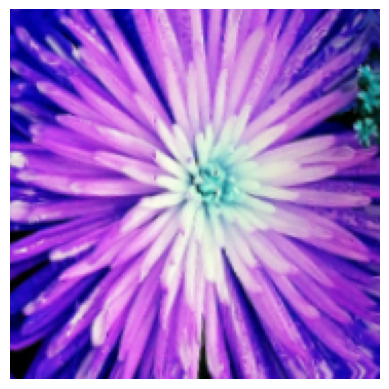

In [26]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Augment your batch
augmented_img = data_augmentation(X)  # X should be a batch of images

# Pick the first image
img = augmented_img[0]

# Convert to uint8 if needed
img = tf.clip_by_value(img, 0, 255)  # or tf.clip_by_value(img, 0,1) if normalized
img = tf.cast(img, tf.uint8)

# Display
plt.axis('off')
plt.imshow(img)
plt.show()


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

num_classes = 5

model = Sequential([
    data_augmentation,  # your data augmentation pipeline

    # 1st convolution block
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # 2nd convolution block
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # 3rd convolution block
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)  # output layer
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Display model summary
model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.2773 - loss: 1.5983
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5270 - loss: 1.1362
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5732 - loss: 1.0387
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.6244 - loss: 0.9682
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6614 - loss: 0.8698
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6642 - loss: 0.8257
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.7020 - loss: 0.7783
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7192 - loss: 0.7336
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7446 - loss: 0.6816
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7374 - loss: 0.6825
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.7553 - loss: 0.6363
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.7576 - 

In [29]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.7342 - loss: 0.8911


[0.9233633875846863, 0.7320261597633362]